# Assignment 9

# Image Classification using Convolutional Neural Networks (CNN)

**Name:** Khushie Brahma

**Assignment Number:** Assignment 9

## Objective

The objective of this assignment is to develop a Convolutional Neural Network (CNN) using TensorFlow/Keras to classify pet images into Cats and Dogs. The model will learn image features using convolution and pooling layers and will be evaluated using classification metrics.

## 1: Import Required Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns

2026-07-31 20:12:39.283545: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2: Load Dataset

In [2]:
dataset_path = "../data/PetImages"

In [3]:
dataset_path = "../data/PetImages"

print("Dataset Path:")
print(dataset_path)

Dataset Path:
../data/PetImages


## 3: Display Folder Structure

In [4]:
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = " " * 4 * (level + 1)

    for file in files[:3]:
        print(f"{subindent}{file}")

PetImages/
    Cat/
        9733.jpg
        63.jpg
        6400.jpg
    Dog/
        9733.jpg
        63.jpg
        6400.jpg


## 4: Data Understanding

In [5]:
classes = sorted(os.listdir(dataset_path))

print("Classes:")
print(classes)

print("\nNumber of Classes:", len(classes))

Classes:
['Cat', 'Dog']

Number of Classes: 2


In [6]:
total_images = 0

for category in classes:
    folder = os.path.join(dataset_path, category)
    total_images += len(os.listdir(folder))

print("Total Images:", total_images)

Total Images: 24998


In [7]:
from PIL import Image

sample_image_path = os.path.join(dataset_path, "Cat", os.listdir(os.path.join(dataset_path, "Cat"))[0])

img = Image.open(sample_image_path)

print("Image Dimensions:", img.size)

Image Dimensions: (365, 500)


### Display Five Sample Images

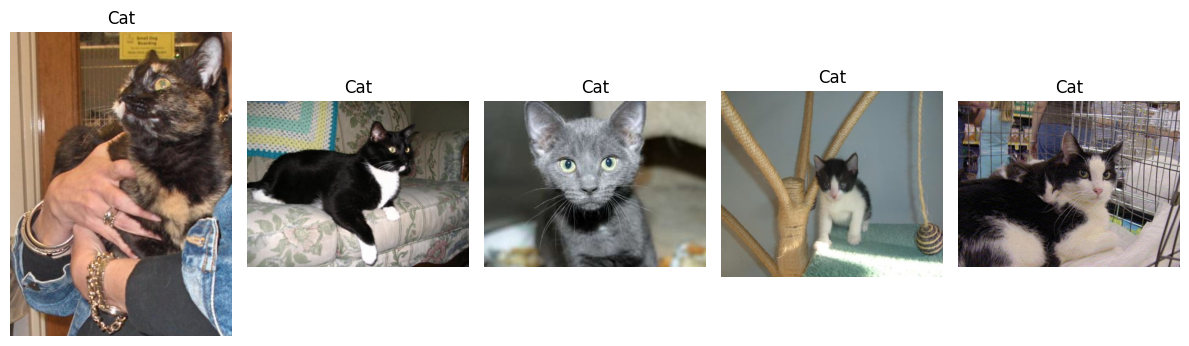

In [8]:
plt.figure(figsize=(12, 8))

for i in range(5):
    img_path = os.path.join(
        dataset_path,
        "Cat",
        os.listdir(os.path.join(dataset_path, "Cat"))[i]
    )

    img = Image.open(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title("Cat")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

The dataset contains two classes: **Cat** and **Dog**. The folder structure is well organized, making it suitable for image classification using TensorFlow/Keras. Sample images were successfully displayed, and the dataset information including the number of classes, image dimensions, and total number of images was identified before preprocessing.

## 5: Data Preprocessing

### Create Training and Testing Datasets

In [9]:
train_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

Found 24998 files belonging to 2 classes.
Using 19999 files for training.


In [10]:
test_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

Found 24998 files belonging to 2 classes.
Using 4999 files for validation.


### Normalize Pixel Values

In [11]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

### Verify Image Shape

In [12]:
for images, labels in train_dataset.take(1):
    print("Batch Shape:", images.shape)
    print("Image Shape:", images[0].shape)
    print("Label Shape:", labels.shape)

Batch Shape: (32, 128, 128, 3)
Image Shape: (128, 128, 3)
Label Shape: (32,)


### Display One Preprocessed Image

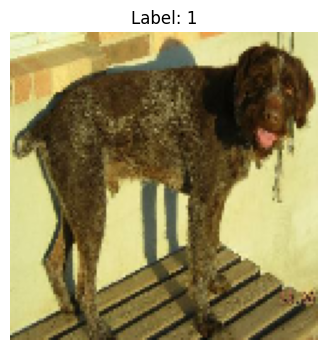

In [14]:
plt.figure(figsize=(4,4))

for images, labels in train_dataset.take(1):
    plt.imshow(images[0].numpy())
    plt.title(f"Label: {labels[0].numpy()}")
    plt.axis("off")

plt.show()

### Observation

The dataset was successfully preprocessed by resizing all images to **128 × 128 pixels**, normalizing pixel values to the range **0–1**, splitting the dataset into **80% training** and **20% testing** sets, and creating TensorFlow/Keras data generators. These preprocessing steps prepare the image dataset for efficient training of the Convolutional Neural Network (CNN).

## 6: Model Development

### Build the Convolutional Neural Network (CNN)

In [15]:
model = models.Sequential([
    
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 128)       0

### Compile the Model

In [17]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Remove Corrupted Images

In [21]:
from PIL import Image
import os

num_skipped = 0

for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join(dataset_path, folder_name)

    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)

        try:
            img = Image.open(fpath)
            img.verify()          # Verify image integrity
            img = Image.open(fpath)

            # Keep only RGB images
            if img.mode != "RGB":
                os.remove(fpath)
                num_skipped += 1

        except Exception:
            os.remove(fpath)
            num_skipped += 1

print("Deleted", num_skipped, "corrupted images.")

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/PIL/TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Deleted 67 corrupted images.


In [26]:
train_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
).ignore_errors()

Found 24931 files belonging to 2 classes.
Using 19945 files for training.


In [27]:
test_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
).ignore_errors()

Found 24931 files belonging to 2 classes.
Using 4986 files for validation.


In [28]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

### Train the Model

In [29]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10,
    verbose=1
)

Epoch 1/10
     76/Unknown - 89s 1s/step - loss: 0.3235 - accuracy: 0.8692

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9


    103/Unknown - 119s 1s/step - loss: 0.3170 - accuracy: 0.8708

Corrupt JPEG data: 252 extraneous bytes before marker 0xd9


    118/Unknown - 134s 1s/step - loss: 0.3121 - accuracy: 0.8742

...

591/621 [===========================>..] - ETA: 43s - loss: 0.0334 - accuracy: 0.9885

Corrupt JPEG data: 162 extraneous bytes before marker 0xd9


621/621 [==============================] - ETA: 0s - loss: 0.0341 - accuracy: 0.9883

Corrupt JPEG data: 65 extraneous bytes before marker 0xd9


621/621 [==============================] - 937s 2s/step - loss: 0.0341 - accuracy: 0.9883 - val_loss: 0.9000 - val_accuracy: 0.8259


## 7: Model Evaluation

### Test Accuracy

In [31]:
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

     29/Unknown - 28s 865ms/step - loss: 0.9664 - accuracy: 0.8093

Corrupt JPEG data: 65 extraneous bytes before marker 0xd9


155/155 [==============================] - 106s 665ms/step - loss: 0.9024 - accuracy: 0.8261
Test Loss: 0.9024
Test Accuracy: 0.8261


### Generate Predictions

In [32]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = (predictions > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Total Test Samples:", len(y_true))
print("Total Predictions:", len(y_pred))

Corrupt JPEG data: 65 extraneous bytes before marker 0xd9


Total Test Samples: 4958
Total Predictions: 4958


### Classification Metrics

In [33]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", round(test_accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 0.8261
Precision: 0.7868
Recall   : 0.8977
F1-Score : 0.8386


In [34]:
print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Cat", "Dog"]
))


Classification Report:

              precision    recall  f1-score   support

         Cat       0.88      0.75      0.81      2446
         Dog       0.79      0.90      0.84      2512

    accuracy                           0.82      4958
   macro avg       0.83      0.82      0.82      4958
weighted avg       0.83      0.82      0.82      4958



### Confusion Matrix

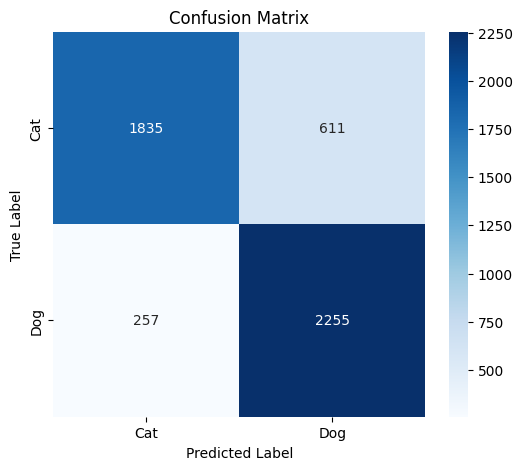

In [35]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig(
    "../images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Accuracy vs Epoch

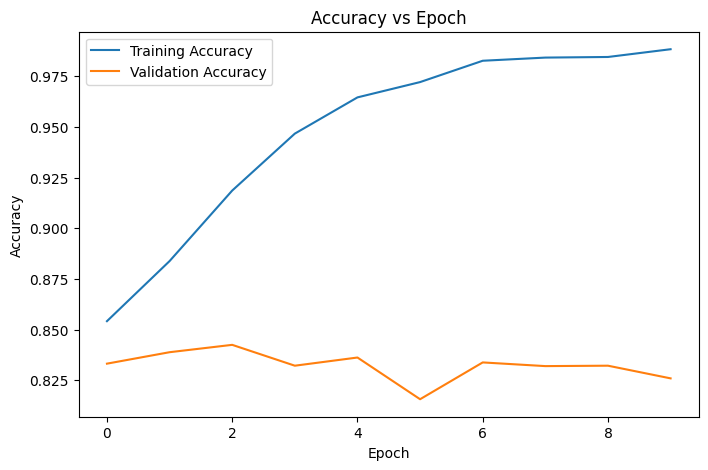

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig(
    "../images/accuracy_vs_epoch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Loss vs Epoch

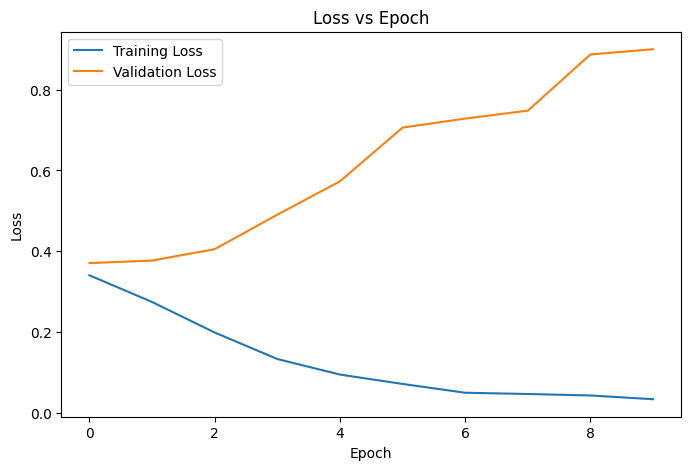

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig(
    "../images/loss_vs_epoch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

1. The CNN achieved a test accuracy of **82.61%**, indicating good overall performance in classifying Cat and Dog images.

2. The model achieved a precision of **78.68%**, recall of **89.77%**, and F1-score of **83.86%**, showing a good balance between classification performance metrics.

3. The classification report shows that the model performed better in identifying Dogs, achieving a recall of **0.90**, compared to a recall of **0.75** for Cats.

4. The model achieved F1-scores of **0.81 for Cats** and **0.84 for Dogs**, indicating reasonably balanced performance across both classes, although some Cat images were misclassified as Dogs.

## 8: Conclusion

The Convolutional Neural Network (CNN) successfully classified Cat and Dog images, achieving a test accuracy of **82.61%**. The model also achieved a precision of **78.68%**, recall of **89.77%**, and F1-score of **83.86%**, demonstrating good overall classification performance. Convolutional layers played an important role in extracting meaningful visual features such as edges, textures, and patterns from the images, while pooling layers reduced the spatial dimensions and computational complexity of the feature maps. A major advantage of CNN over a traditional ANN is its ability to automatically learn spatial features from image data while preserving local relationships between pixels. However, CNNs can require significant computational resources and training time, especially when working with large image datasets. Overall, the CNN provided an effective approach for binary image classification.